In [1]:
import pandas as pd
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import plotly.express as px
import math

print("halo")

halo


In [3]:
neigh_count = df.groupby("neighbourhood_cleansed").size().reset_index(name="jumlah_listing")
print(neigh_count.sort_values("jumlah_listing", ascending=False))

     neighbourhood_cleansed  jumlah_listing
12            Jamaica Plain             330
22                South End             318
1                  Back Bay             297
10                   Fenway             281
7                Dorchester             258
0                   Allston             248
3               Beacon Hill             189
4                  Brighton             175
20             South Boston             173
8                  Downtown             166
9               East Boston             148
17                North End             142
19                  Roxbury             139
16             Mission Hill             123
5               Charlestown             108
21  South Boston Waterfront              82
6                 Chinatown              70
18               Roslindale              55
23                 West End              47
24             West Roxbury              45
11                Hyde Park              30
2               Bay Village     

In [5]:
# hitung jumlah listing per neighbourhood
neigh_count = df["neighbourhood_cleansed"].value_counts().reset_index()

# rapikan nama kolom
neigh_count.columns = ["neighbourhood", "jumlah_listing"]

print(neigh_count.head(24))   # preview 10 teratas

              neighbourhood  jumlah_listing
0             Jamaica Plain             330
1                 South End             318
2                  Back Bay             297
3                    Fenway             281
4                Dorchester             258
5                   Allston             248
6               Beacon Hill             189
7                  Brighton             175
8              South Boston             173
9                  Downtown             166
10              East Boston             148
11                North End             142
12                  Roxbury             139
13             Mission Hill             123
14              Charlestown             108
15  South Boston Waterfront              82
16                Chinatown              70
17               Roslindale              55
18                 West End              47
19             West Roxbury              45
20                Hyde Park              30
21              Bay Village     

In [28]:
periods = [30, 60, 90, 365]
for P in periods:
    occ_col = f"days_occupied_{P}"          # ambil kolom occupied sesuai periode
    rate_col = f"occupancy_rate_{P} (%)"        # nama kolom baru
    
    if occ_col in df.columns:  # cek kolomnya ada
        df[rate_col] = (df[occ_col] / P * 100).clip(lower=0).fillna(0).round(2)  # persen, bukan int

df.to_csv("AirBnb_data_case-study/Best_Property/listings_clean.csv", index=False)

print("✅ File sudah tersalin ke AirBnb_data_case-study/Best_Property/listings_clean.csv")

✅ File sudah tersalin ke AirBnb_data_case-study/Best_Property/listings_clean.csv


In [25]:
for p in [30, 60, 90, 365]:
    col = f"occupancy_rate_{p}%"
    if col in df.columns:
        df = df.drop(columns=[col])

print("sudah dihapus")

sudah dihapus


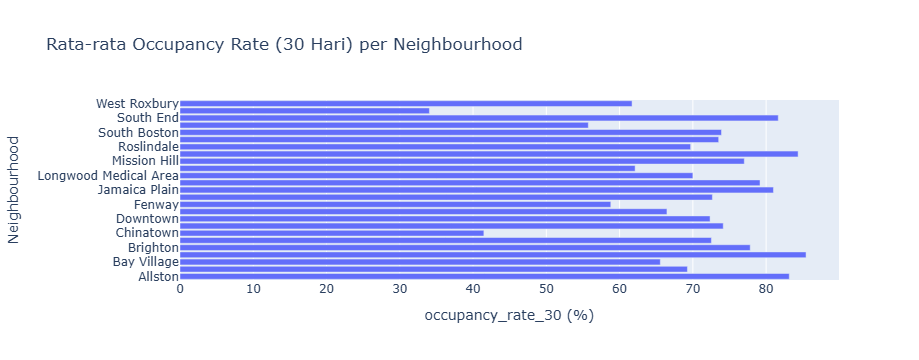

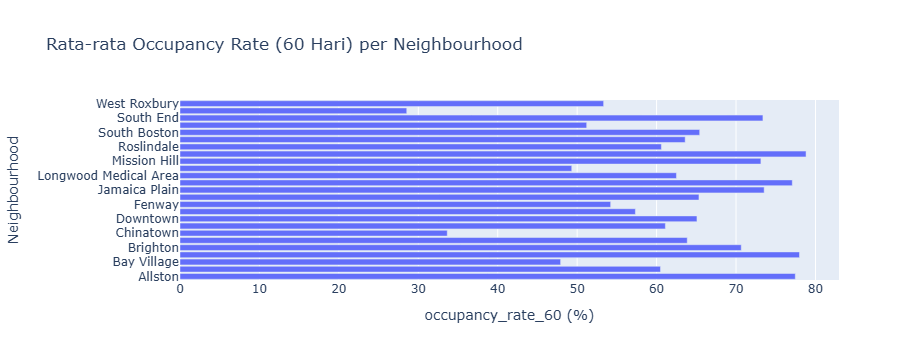

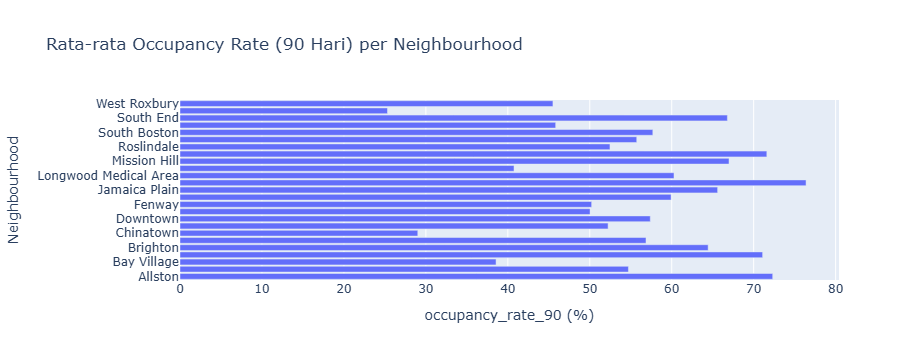

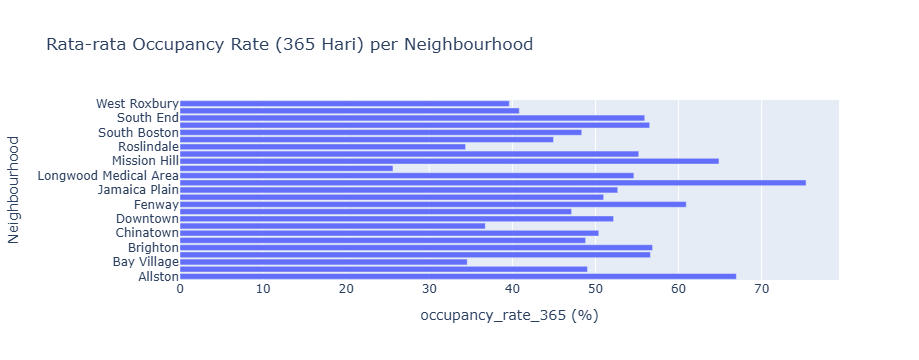

In [26]:
# bikin bar chart rata-rata occupancy rate per neighbourhood (contoh pakai occ_rate_30)
neigh_occ1 = df.groupby("neighbourhood_cleansed")["occupancy_rate_30 (%)"].mean().reset_index()
neigh_occ2 = df.groupby("neighbourhood_cleansed")["occupancy_rate_60 (%)"].mean().reset_index()
neigh_occ3 = df.groupby("neighbourhood_cleansed")["occupancy_rate_90 (%)"].mean().reset_index()
neigh_occ4 = df.groupby("neighbourhood_cleansed")["occupancy_rate_365 (%)"].mean().reset_index()

fig = px.bar(
    neigh_occ1,
    x="occupancy_rate_30 (%)",
    y="neighbourhood_cleansed",
    orientation="h",
    title="Rata-rata Occupancy Rate (30 Hari) per Neighbourhood",
    labels={"occ_rate_30":"Occupancy Rate (%)","neighbourhood_cleansed":"Neighbourhood"}
)
fig.show()

fig = px.bar(
    neigh_occ2,
    x="occupancy_rate_60 (%)",
    y="neighbourhood_cleansed",
    orientation="h",
    title="Rata-rata Occupancy Rate (60 Hari) per Neighbourhood",
    labels={"occ_rate_30":"Occupancy Rate (%)","neighbourhood_cleansed":"Neighbourhood"}
)
fig.show()

fig = px.bar(
    neigh_occ3,
    x="occupancy_rate_90 (%)",
    y="neighbourhood_cleansed",
    orientation="h",
    title="Rata-rata Occupancy Rate (90 Hari) per Neighbourhood",
    labels={"occ_rate_30":"Occupancy Rate (%)","neighbourhood_cleansed":"Neighbourhood"}
)
fig.show()

fig = px.bar(
    neigh_occ4,
    x="occupancy_rate_365 (%)",
    y="neighbourhood_cleansed",
    orientation="h",
    title="Rata-rata Occupancy Rate (365 Hari) per Neighbourhood",
    labels={"occ_rate_30":"Occupancy Rate (%)","neighbourhood_cleansed":"Neighbourhood"}
)
fig.show()

# LEATHER DISTRICT IS GOOD RECOMMENDATION